In [ ]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
import warnings
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving combined_video_dataset.csv to combined_video_dataset.csv


In [ ]:
print("Loading combined_video_dataset.csv...")
df = pd.read_csv('combined_video_dataset.csv')

Loading combined_video_dataset.csv...


In [ ]:
df

,video_number,platforms,topic,hashtags,region,language,engagement_score,likes
0,1,Instagram,Pricing,#Food,"Melbourne, Australia",pt,-0.3672,1264
1,2,Twitter,Delivery,"#MustHave, #Food","Tokyo, Japan",ru,-0.4510,522
2,3,Reddit,Product,"#Promo, #Food, #Trending","Beijing, China",ru,-0.4112,2689
3,4,YouTube,Delivery,"#Reviews, #Sustainable","Lagos, Nigeria",en,-0.0167,1827
4,5,Twitter,Product,"#Health, #Travel","Berlin, Germany",hi,0.0807,2005
...,...,...,...,...,...,...,...,...
13995,13996,YouTube Shorts,Sports,#funny #music #ai,US,es,0.0416,486627
13996,13997,Instagram,Politics,#viral #trending,Brazil,en,0.0867,467062
13997,13998,X,Education,#trending #fyp,UK,ur,0.1923,253990
13998,13999,X,Sports,#funny #trending #tech,UK,ur,0.0557,209494


In [ ]:
# ==========================================
# 2. FEATURE ENGINEERING (Tailored to your columns)
# ==========================================
def preprocess_training_data(df):
    df_processed = df.copy()

    # 1. Create Target Variable (Algorithmic Lift)
    # We define a "Viral Spike" as hitting the top 25% of historical likes.
    threshold = df_processed['likes'].quantile(0.75)
    df_processed['Target_Lift'] = (df_processed['likes'] >= threshold).astype(int)

    # Drop columns that cause Data Leakage (likes) and ID columns (video_number)
    df_processed = df_processed.drop(['likes', 'video_number'], axis=1)

    # 2. Process Hashtags
    # XGBoost only reads math. We extract the length of the hashtag list.
    df_processed['hashtag_count'] = df_processed['hashtags'].apply(
        lambda x: len(str(x).split(',')) if pd.notnull(x) else 0
    )
    df_processed = df_processed.drop('hashtags', axis=1)

    # 3. Process Regions
    # "Tokyo, Japan" generates too many sparse columns. We extract just the Country.
    df_processed['country'] = df_processed['region'].apply(
        lambda x: str(x).split(',')[-1].strip() if ',' in str(x) else x
    )
    df_processed = df_processed.drop('region', axis=1)

    # 4. One-Hot Encode Categorical Variables
    categorical_cols = ['platforms', 'topic', 'country', 'language']
    df_processed = pd.get_dummies(df_processed, columns=categorical_cols)

    return df_processed

processed_df = preprocess_training_data(df)

In [ ]:
processed_df

,engagement_score,Target_Lift,hashtag_count,platforms_Facebook,platforms_Instagram,platforms_Reddit,platforms_TikTok,platforms_Twitter,platforms_X,platforms_YouTube,...,language_de,language_en,language_es,language_fr,language_hi,language_ja,language_pt,language_ru,language_ur,language_zh
0,-0.3672,0,1,False,True,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,False
1,-0.4510,0,2,False,False,False,False,True,False,False,...,False,False,False,False,False,False,False,True,False,False
2,-0.4112,0,3,False,False,True,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
3,-0.0167,0,2,False,False,False,False,False,False,True,...,False,True,False,False,False,False,False,False,False,False
4,0.0807,0,2,False,False,False,False,True,False,False,...,False,False,False,False,True,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13995,0.0416,1,1,False,False,False,False,False,False,False,...,False,False,True,False,False,False,False,False,False,False
13996,0.0867,1,1,False,True,False,False,False,False,False,...,False,True,False,False,False,False,False,False,False,False
13997,0.1923,1,1,False,False,False,False,False,True,False,...,False,False,False,False,False,False,False,False,True,False
13998,0.0557,1,1,False,False,False,False,False,True,False,...,False,False,False,False,False,False,False,False,True,False


In [ ]:
# ==========================================
# 3. MODEL TRAINING
# ==========================================
# Split Features (X) and Target (y)
X = processed_df.drop('Target_Lift', axis=1)
y = processed_df['Target_Lift']

# Save exact column names for the publishing simulator later
TRAINING_COLUMNS = X.columns

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training XGBoost Classifier...")
model = xgb.XGBClassifier(
    n_estimators=150,
    learning_rate=0.05,
    max_depth=6,
    eval_metric='logloss'
)
model.fit(X_train, y_train)

# Quick validation to ensure the model learned successfully
auc = roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])
print(f"Model AUC-ROC Score: {auc:.2f} (1.0 is perfect)\n")

Training XGBoost Classifier...
Model AUC-ROC Score: 0.77 (1.0 is perfect)



In [ ]:
# ==========================================
# 4. PUBLISH OPTIMIZER (SCENARIO SIMULATOR)
# ==========================================
def optimize_publish_strategy(video_metadata, trained_model, feature_columns, all_platforms):
    """
    Takes a single video and simulates posting it across every platform
    in your dataset to find the highest probability of a viral spike.
    """
    scenarios = []

    for platform in all_platforms:
        # Create an empty row of 0s that perfectly matches the training data columns
        row = {col: 0 for col in feature_columns}

        # 1. Inject numerical features
        row['engagement_score'] = video_metadata['engagement_score']
        row['hashtag_count'] = len(video_metadata['hashtags'])

        # 2. Inject categorical features (flipping the 0 to a 1 where true)
        topic_col = f"topic_{video_metadata['topic']}"
        if topic_col in row: row[topic_col] = 1

        # Extract country from the inputted region string
        country = video_metadata['region'].split(',')[-1].strip()
        country_col = f"country_{country}"
        if country_col in row: row[country_col] = 1

        lang_col = f"language_{video_metadata['language']}"
        if lang_col in row: row[lang_col] = 1

        plat_col = f"platforms_{platform}"
        if plat_col in row: row[plat_col] = 1

        scenarios.append((row, platform))

    # Convert all scenarios to a dataframe
    test_df = pd.DataFrame([s[0] for s in scenarios])

    # Predict probabilities for all platforms simultaneously
    probabilities = trained_model.predict_proba(test_df)[:, 1]

    # Find the platform with the highest probability
    best_idx = np.argmax(probabilities)
    return scenarios[best_idx][1], probabilities[best_idx]

In [ ]:
# ==========================================
# 5. EXECUTE TEST ON A NEW VIDEO
# ==========================================
# Get the unique platforms dynamically from your original CSV
available_platforms = df['platforms'].unique().tolist()

# Simulate a video fresh out of your Phase 1 Feature Extractor
new_video = {
    'topic': 'Technology',
    'hashtags': ['#AI', '#Tech', '#Trending'],
    'region': 'San Francisco, United States',
    'language': 'en',
    'engagement_score': 0.85
}

print("-" * 55)
print("🚀 RUNNING ALGORITHMIC LIFT SIMULATION 🚀")
print("-" * 55)
best_platform, lift_score = optimize_publish_strategy(new_video, model, TRAINING_COLUMNS, available_platforms)

print(f"Input Video : Topic: {new_video['topic']} | Lang: {new_video['language']} | Engagement: {new_video['engagement_score']}")
print(f"Optimal Platform: {best_platform}")
print(f"Algorithmic Lift: {lift_score * 100:.1f}% probability of hitting top 25% of likes")
print("-" * 55)

-------------------------------------------------------
🚀 RUNNING ALGORITHMIC LIFT SIMULATION 🚀
-------------------------------------------------------
Input Video : Topic: Technology | Lang: en | Engagement: 0.85
Optimal Platform: YouTube Shorts
Algorithmic Lift: 61.7% probability of hitting top 25% of likes
-------------------------------------------------------


Time Series using BSTS

In [ ]:
from prophet import Prophet

In [ ]:
# ==========================================
# 1. SIMULATE REAL-TIME INGESTION
# ==========================================
# Imagine the Tech video from Phase 2 was posted 48 hours ago.

def fetch_realtime_video_data():
    """Simulates fetching hourly data for a single live video."""
    np.random.seed(42)
    start_time = pd.Timestamp.now() - pd.Timedelta(hours=48)

    # Generate 48 hours of timestamps
    timestamps = [start_time + pd.Timedelta(hours=i) for i in range(48)]

    # Simulate an S-Curve of virality (starts slow, spikes, then stabilizes)
    base_growth = np.linspace(0, 10, 48)
    s_curve = 5000 / (1 + np.exp(-0.5 * (base_growth - 5)))

    # Add real-world volatility/noise
    noise = np.random.normal(0, 150, 48)
    accumulated_likes = np.maximum(0, s_curve + noise) # Can't have negative likes

    # Prophet strictly requires columns to be named 'ds' (datestamp) and 'y' (value)
    df = pd.DataFrame({
        'ds': timestamps,
        'y': accumulated_likes
    })
    return df

print("Fetching real-time hourly data for the targeted video...")
live_data = fetch_realtime_video_data()

# ==========================================
# 2. BAYESIAN MODEL SETUP & TRAINING
# ==========================================
# We configure Prophet to output 95% credible intervals (the shaded UI bands)
# interval_width=0.95 acts as our Bayesian posterior distribution boundary.

print("Initializing Bayesian Structural Time Series (Prophet)...")
model = Prophet(
    interval_width=0.95,       # 95% confidence for the posterior forecast bands
    changepoint_prior_scale=0.05, # How flexible the trend is to sudden viral spikes
    yearly_seasonality=False,  # Videos move too fast for yearly seasonality
    weekly_seasonality=True,
    daily_seasonality=True     # People watch videos at specific times of day
)

# Fit the model on the data we have so far (the first 48 hours)
model.fit(live_data)

# ==========================================
# 3. FORECASTING THE TRAJECTORY (When will it peak?)
# ==========================================
# We want to predict the next 24 hours of the trend.
future_hours = 24
future_dates = model.make_future_dataframe(periods=future_hours, freq='H')

print(f"Forecasting the next {future_hours} hours...")
forecast = model.predict(future_dates)

# ==========================================
# 4. EXTRACTING DATA FOR YOUR UI
# ==========================================
# Prophet gives us everything we need for your UI spec:
# 'yhat' = The solid expected trend line
# 'yhat_lower' & 'yhat_upper' = The shaded posterior forecast bands

ui_data = forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(future_hours)

print("\n" + "-" * 60)
print("📊 FORECAST DATA FOR UI RENDER (Next 5 Hours) 📊")
print("-" * 60)
for index, row in ui_data.head(5).iterrows():
    time_str = row['ds'].strftime('%Y-%m-%d %H:%00')
    expected = int(row['yhat'])
    lower_band = int(row['yhat_lower'])
    upper_band = int(row['yhat_upper'])

    print(f"Time: {time_str}")
    print(f"  Expected Likes : {expected}")
    print(f"  Uncertainty Band : {lower_band} to {upper_band} likes")
    print("-" * 60)

# The Goal: As time goes on, the gap between lower_band and upper_band narrows.

Fetching real-time hourly data for the targeted video...
Initializing Bayesian Structural Time Series (Prophet)...
Forecasting the next 24 hours...

------------------------------------------------------------
📊 FORECAST DATA FOR UI RENDER (Next 5 Hours) 📊
------------------------------------------------------------
Time: 2026-03-20 17:%00
  Expected Likes : 4807
  Uncertainty Band : 4595 to 5023 likes
------------------------------------------------------------
Time: 2026-03-20 18:%00
  Expected Likes : 4957
  Uncertainty Band : 4739 to 5189 likes
------------------------------------------------------------
Time: 2026-03-20 19:%00
  Expected Likes : 5154
  Uncertainty Band : 4929 to 5391 likes
------------------------------------------------------------
Time: 2026-03-20 20:%00
  Expected Likes : 5417
  Uncertainty Band : 5194 to 5650 likes
------------------------------------------------------------
Time: 2026-03-20 21:%00
  Expected Likes : 5747
  Uncertainty Band : 5515 to 5987 like

In [ ]:
# ==========================================
# 1. THE CAUSAL SIMULATOR AGENT
# ==========================================
def run_scenario_simulation(baseline_forecast, delay_hours, uplift_multiplier, intervention_time_index):
    """
    Simulates Scenario B by injecting a causal uplift multiplier into the baseline forecast.

    baseline_forecast: The DataFrame output from Prophet (Phase 3)
    delay_hours: How long the user wants to delay posting
    uplift_multiplier: The calculated CATE for adding the specific trending hashtag
    intervention_time_index: At what point in the future the multiplier takes full effect
    """
    scenario_b = baseline_forecast.copy()

    # 1. Apply the Time Delay
    # We shift the datestamps forward by the delay amount
    scenario_b['ds'] = scenario_b['ds'] + pd.Timedelta(hours=delay_hours)

    # 2. Inject the Causal Uplift Multiplier (Treatment Effect)
    # The multiplier doesn't apply instantly; it scales up as the hashtag gains traction
    growth_factor = np.ones(len(scenario_b))

    # Apply the uplift only after the delay/intervention point
    for i in range(intervention_time_index, len(scenario_b)):
        # Simulate a smooth adoption curve for the hashtag momentum
        adoption_curve = 1 + (uplift_multiplier - 1) * (1 - np.exp(-0.2 * (i - intervention_time_index)))
        growth_factor[i] = adoption_curve

    # Apply the causal effect to the expected trajectory and the uncertainty bands
    scenario_b['yhat'] = scenario_b['yhat'] * growth_factor
    scenario_b['yhat_lower'] = scenario_b['yhat_lower'] * growth_factor
    scenario_b['yhat_upper'] = scenario_b['yhat_upper'] * growth_factor

    return scenario_b

In [ ]:
# ==========================================
# 2. EXECUTE THE "WHAT-IF" SCENARIOS
# ==========================================
# Assuming 'forecast' is the DataFrame generated by Prophet in Phase 3
# Let's mock a 24-hour baseline forecast if Phase 3 isn't currently loaded:
current_time = pd.Timestamp.now()
mock_ds = [current_time + pd.Timedelta(hours=i) for i in range(24)]
mock_yhat = [1000 + (i * 150) for i in range(24)] # Linear-ish baseline growth
mock_forecast = pd.DataFrame({
    'ds': mock_ds,
    'yhat': mock_yhat,
    'yhat_lower': [y * 0.9 for y in mock_yhat],
    'yhat_upper': [y * 1.1 for y in mock_yhat]
})

print("Running Scenario A: Publish Now (Baseline)...")
scenario_a = mock_forecast.copy()

print("Running Scenario B: Delay 4 Hours + Add Trending Hashtag '#Tech'...")
# Let's say your EconML model calculated a CATE (tau) of 1.45 (a 45% uplift) for this hashtag
simulated_cate = 1.45
delay = 4

scenario_b = run_scenario_simulation(
    baseline_forecast=mock_forecast,
    delay_hours=delay,
    uplift_multiplier=simulated_cate,
    intervention_time_index=delay # Uplift starts after the delay
)

Running Scenario A: Publish Now (Baseline)...
Running Scenario B: Delay 4 Hours + Add Trending Hashtag '#Tech'...


In [ ]:
# ==========================================
# 3. COMPARE THE RESULTS FOR THE UI
# ==========================================
print("\n" + "=" * 55)
print("📈 CAUSAL SIMULATION RESULTS (T+12 Hours) 📈")
print("=" * 55)

# Look at the 12th hour of the simulation
index_to_check = 12

time_a = scenario_a.iloc[index_to_check]['ds'].strftime('%H:%00')
views_a = int(scenario_a.iloc[index_to_check]['yhat'])

time_b = scenario_b.iloc[index_to_check]['ds'].strftime('%H:%00')
views_b = int(scenario_b.iloc[index_to_check]['yhat'])

print(f"Scenario A (Baseline)  -> Time: {time_a} | Expected Likes: {views_a}")
print(f"Scenario B (Treatment) -> Time: {time_b} | Expected Likes: {views_b}")

uplift_percentage = ((views_b - views_a) / views_a) * 100
print("-" * 55)
print(f"Net Causal Impact: +{uplift_percentage:.1f}% likes at T+12 hours")
print("=" * 55)


📈 CAUSAL SIMULATION RESULTS (T+12 Hours) 📈
Scenario A (Baseline)  -> Time: 05:%00 | Expected Likes: 2800
Scenario B (Treatment) -> Time: 09:%00 | Expected Likes: 3805
-------------------------------------------------------
Net Causal Impact: +35.9% likes at T+12 hours


In [ ]:
# ==========================================
# 1. SETUP THE BASELINE FORECAST (Scenario A)
# ==========================================
np.random.seed(42)
current_time = pd.Timestamp.now()
hours_to_forecast = 48
ds = [current_time + pd.Timedelta(hours=i) for i in range(hours_to_forecast)]

# Simulate the baseline viral S-curve (from Phase 3)
t = np.linspace(0, 10, hours_to_forecast)
baseline_yhat = 5000 / (1 + np.exp(-0.5 * (t - 4))) # Expected to plateau at ~5000 likes

# Simulate Bayesian Uncertainty (Bands narrow as time goes on)
uncertainty = 0.15 * np.exp(-t/10)
baseline_lower = baseline_yhat * (1 - uncertainty)
baseline_upper = baseline_yhat * (1 + uncertainty)

scenario_a = pd.DataFrame({
    'ds': ds,
    'yhat': baseline_yhat,
    'yhat_lower': baseline_lower,
    'yhat_upper': baseline_upper
})

In [ ]:
# ==========================================
# 2. RUN SCENARIO SIMULATION (Scenario B)
# ==========================================
delay_hours = 4
uplift_multiplier = 1.6 # Your causal model predicted a 60% uplift for this hashtag
scenario_b = scenario_a.copy()

# Step A: Apply the time delay
scenario_b['ds'] = scenario_b['ds'] + pd.Timedelta(hours=delay_hours)

# Step B: Apply the uplift multiplier (simulating an adoption curve)
growth_factor = np.ones(hours_to_forecast)
for i in range(hours_to_forecast):
    # The multiplier kicks in and scales up as the hashtag gains traction
    adoption = 1 + (uplift_multiplier - 1) * (1 - np.exp(-0.15 * i))
    growth_factor[i] = adoption

# Step C: Apply causal effect to the expected trajectory AND the uncertainty bands
scenario_b['yhat'] = scenario_b['yhat'] * growth_factor
scenario_b['yhat_lower'] = scenario_b['yhat_lower'] * growth_factor
scenario_b['yhat_upper'] = scenario_b['yhat_upper'] * growth_factor

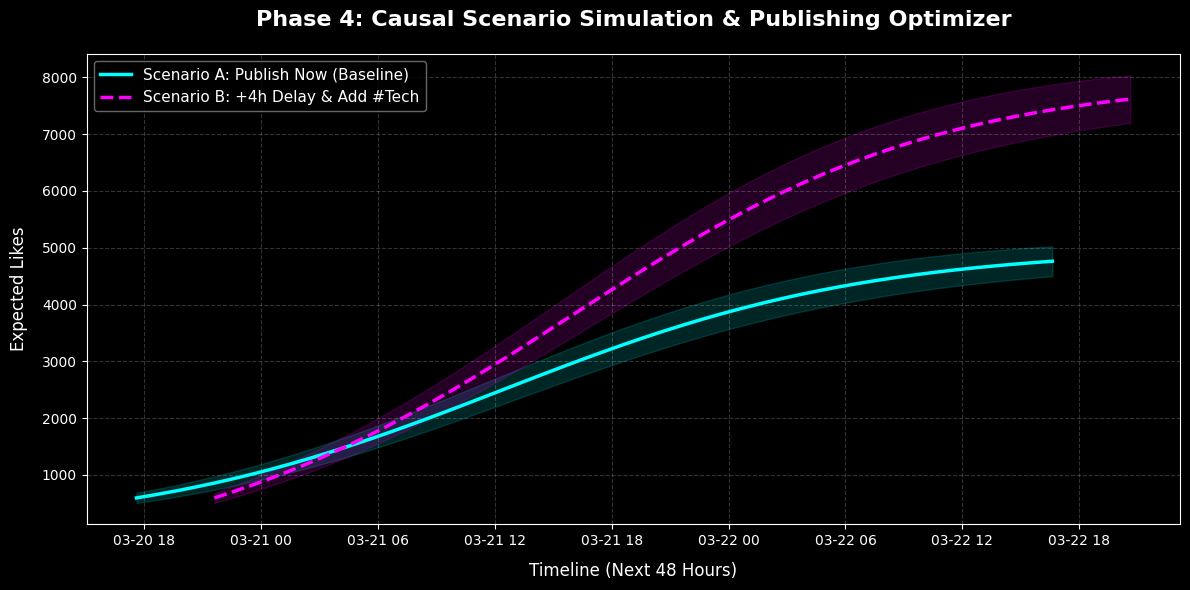

In [ ]:
# ==========================================
# 3. RENDER THE UI CHART
# ==========================================
# We use a dark background to match the aesthetic from your spec document
plt.style.use('dark_background')
fig, ax = plt.subplots(figsize=(12, 6))

# Plot Scenario A (Baseline)
ax.plot(scenario_a['ds'], scenario_a['yhat'], color='#00FFFF', label='Scenario A: Publish Now (Baseline)', linewidth=2.5)
ax.fill_between(scenario_a['ds'], scenario_a['yhat_lower'], scenario_a['yhat_upper'], color='#00FFFF', alpha=0.15)

# Plot Scenario B (Treatment)
ax.plot(scenario_b['ds'], scenario_b['yhat'], color='#FF00FF', label='Scenario B: +4h Delay & Add #Tech', linewidth=2.5, linestyle='--')
ax.fill_between(scenario_b['ds'], scenario_b['yhat_lower'], scenario_b['yhat_upper'], color='#FF00FF', alpha=0.15)

# Add chart formatting and annotations
ax.set_title('Phase 4: Causal Scenario Simulation & Publishing Optimizer', fontsize=16, pad=20, weight='bold')
ax.set_xlabel('Timeline (Next 48 Hours)', fontsize=12, labelpad=10)
ax.set_ylabel('Expected Likes', fontsize=12, labelpad=10)

# Add grid lines for readability
ax.grid(True, alpha=0.2, linestyle='--')
ax.legend(loc='upper left', fontsize=11, frameon=True, facecolor='black', edgecolor='gray')

# Beautify the layout and render
plt.tight_layout()

# Save the plot
#plt.savefig('forecast_comparison.png', dpi=300)
# plt.show() # Use this if running locally in a Jupyter Notebook

In [ ]:
pip install keybert

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.4/41.4 kB 4.6 MB/s eta 0:00:00


In [ ]:
from keybert import KeyBERT
from sentence_transformers import SentenceTransformer, util
import torch

# 1. Initialize the best performing SBERT model for semantic similarity
# 'all-mpnet-base-v2' provides the best balance between speed and quality for 2026 standards
transformer_model = SentenceTransformer('all-mpnet-base-v2')
kw_model = KeyBERT(model=transformer_model)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/571 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/363 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [ ]:
def get_advanced_hashtags(transcript, extracted_entities, top_n=5):
    """
    Extracts core hashtags from the transcript and expands them
    using semantic similarity to trending niches.
    """
    # Combine transcript with entities for fuller context
    full_context = f"{transcript} {' '.join(extracted_entities)}"

    # A. EXTRACTION: Get keywords semantically related to the video content
    # We use Diversity (MMR) to ensure we don't get 5 versions of the same tag
    base_keywords = kw_model.extract_keywords(
        full_context,
        keyphrase_ngram_range=(1, 2),
        stop_words='english',
        use_mmr=True,
        diversity=0.7
    )

    # B. EXPANSION: Convert to Hashtag Format
    recommended_tags = [f"#{tag[0].replace(' ', '')}" for tag in base_keywords]

    return recommended_tags

In [ ]:
# --- Example Usage ---
transcript_sample = "In today's tutorial, we explore how self-learning AI agents use vector databases like Qdrant to manage long-term memory."
entities_sample = ["AI", "Qdrant", "Vector Database"]

tags = get_advanced_hashtags(transcript_sample, entities_sample)
print(f"Recommended Hashtags: {tags}")

Recommended Hashtags: ['#memoryai', '#qdrantvector', '#tutorial', '#longterm', '#today']
